In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression ,Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [2]:
# df=pd.read_csv(r'D:\notebook\housing.csv')
data=fetch_california_housing(as_frame=True)
df=pd.concat([data.data,data.target.rename('Houseprice')],axis=1)

In [3]:
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Houseprice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Houseprice
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Houseprice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.shape

(20640, 9)

In [7]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Houseprice'],
      dtype='str')

In [8]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Houseprice    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
numeric_columns=df.select_dtypes(include='number').columns


In [11]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Houseprice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


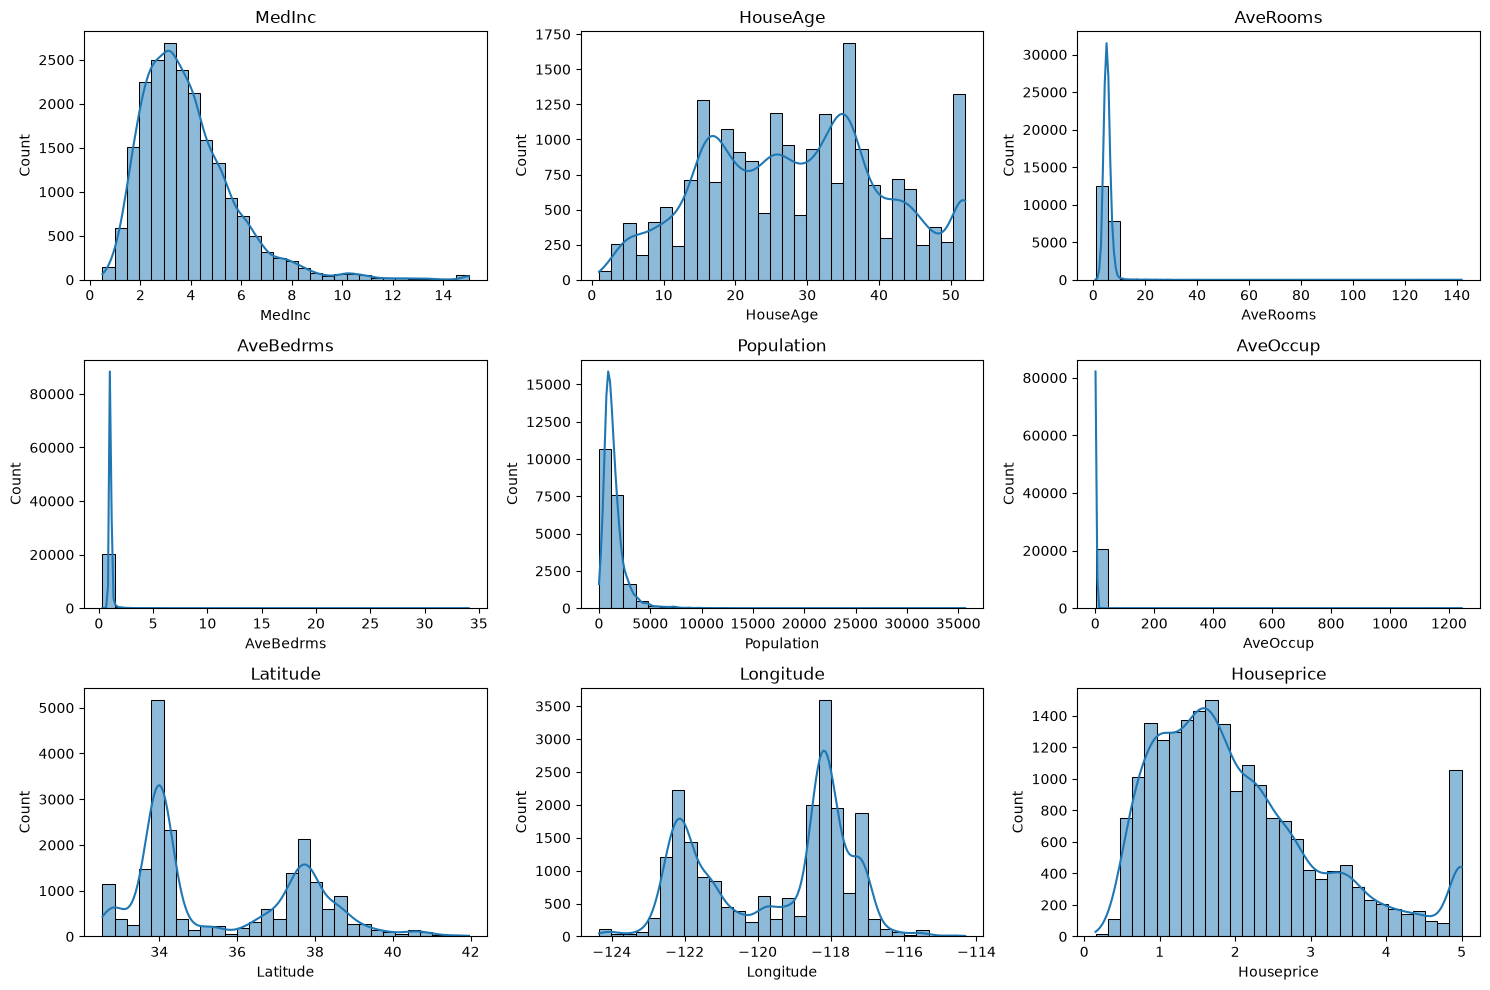

In [12]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
print(df[numeric_columns].skew())

MedInc         1.646657
HouseAge       0.060331
AveRooms      20.697869
AveBedrms     31.316956
Population     4.935858
AveOccup      97.639561
Latitude       0.465953
Longitude     -0.297801
Houseprice     0.977763
dtype: float64


In [14]:
cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for col in cols:
    df[col] = np.log1p(df[col])

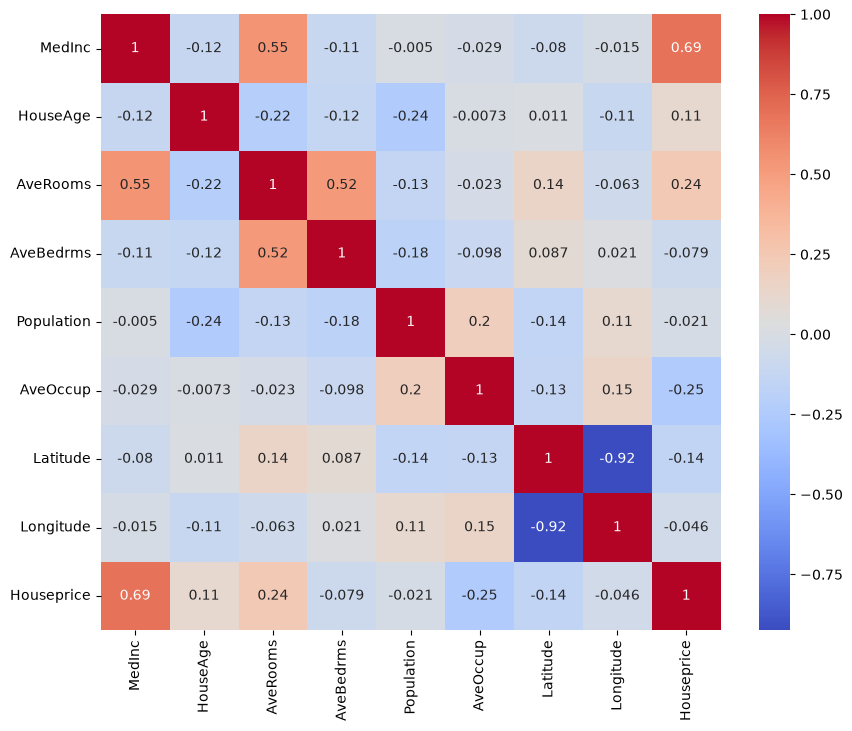

In [15]:
correlation = df[numeric_columns].corr()
plt.figure(figsize=(10, 8))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.show()

In [16]:
df[numeric_columns].corr()['Houseprice'].sort_values(ascending=False)

Houseprice    1.000000
MedInc        0.688075
AveRooms      0.241034
HouseAge      0.105623
Population   -0.021205
Longitude    -0.045967
AveBedrms    -0.079268
Latitude     -0.144160
AveOccup     -0.247044
Name: Houseprice, dtype: float64

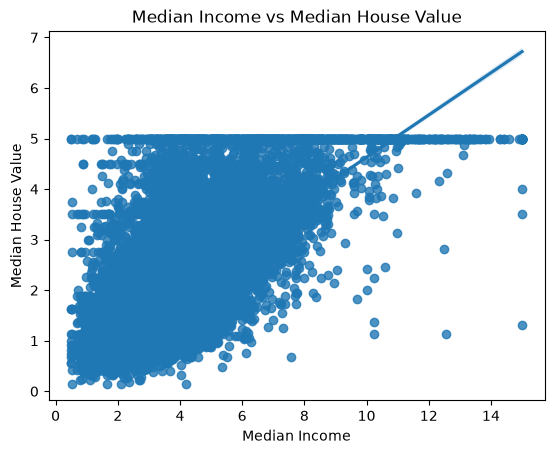

In [17]:
sns.regplot(data=df, x='MedInc', y='Houseprice')

plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

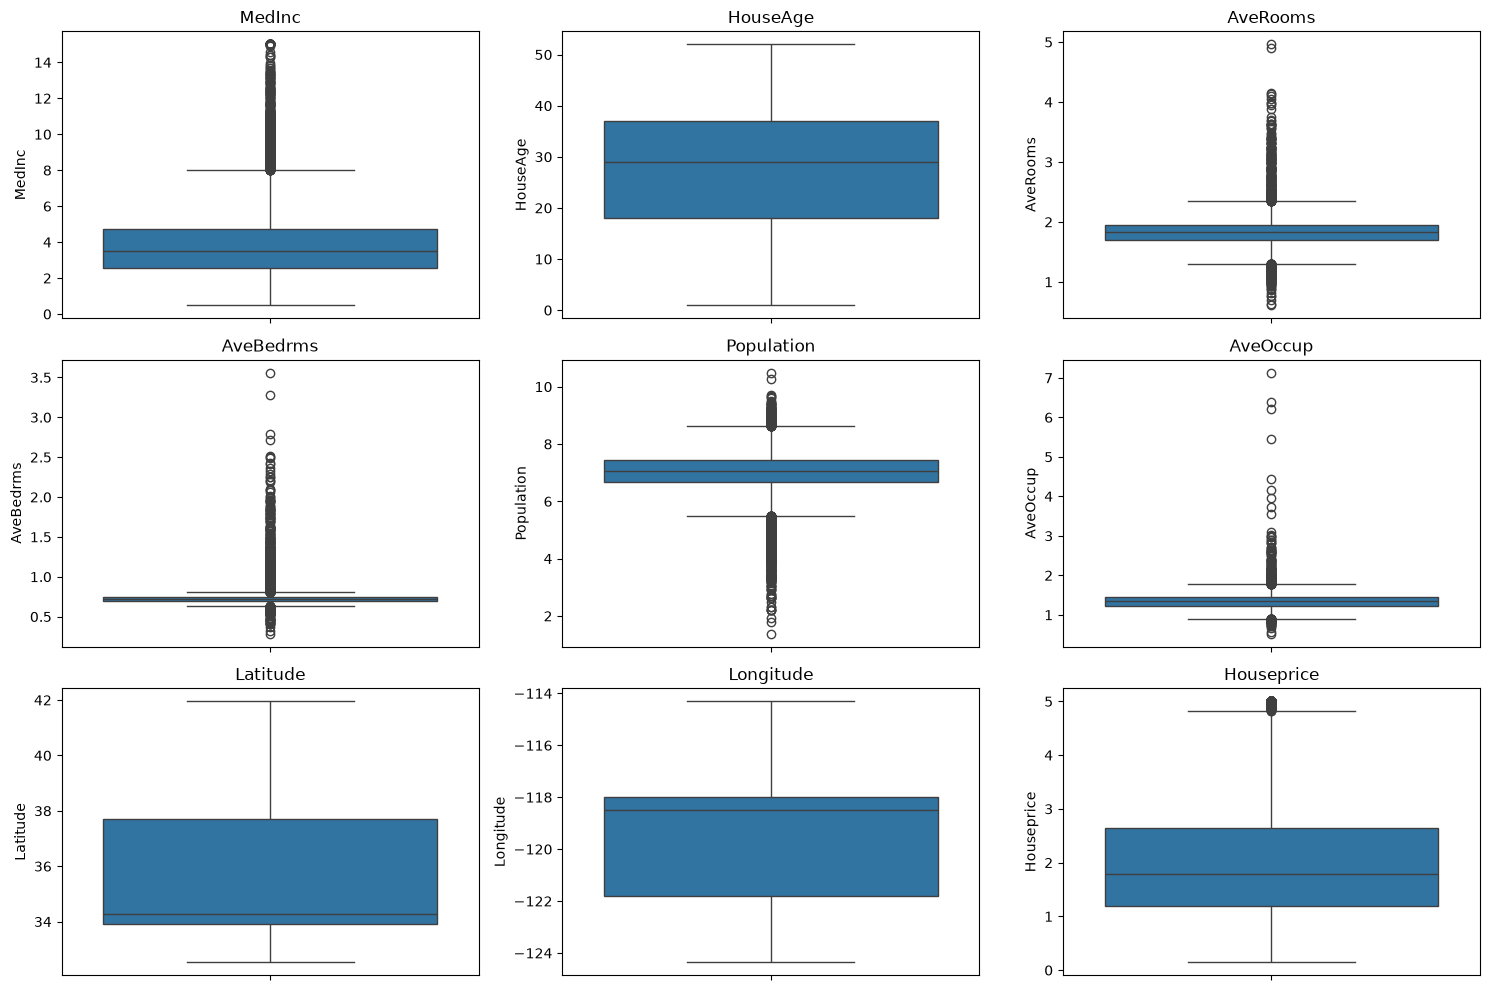

In [18]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
X = df.drop('Houseprice', axis=1)
y = df['Houseprice']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
models = {
    'Linear Regression':LinearRegression(),
    'Ridge Regression' :Ridge(alpha=1.0),
    'Decision Tree ': DecisionTreeRegressor(max_depth=5)
}


result={}
for name, model in models.items():
    model.fit(X_train,y_train)
    predictions=model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test,predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)
    result[name]={
    'MAE':mae,
    'MSE':mse,
    'RSME':rmse,
    'R2':r2
    }
results_df = pd.DataFrame(result).T

print(results_df)

                        MAE       MSE      RSME        R2
Linear Regression  0.493417  0.466854  0.683267  0.643734
Ridge Regression   0.493450  0.466766  0.683203  0.643801
Decision Tree      0.522259  0.524515  0.724234  0.599732


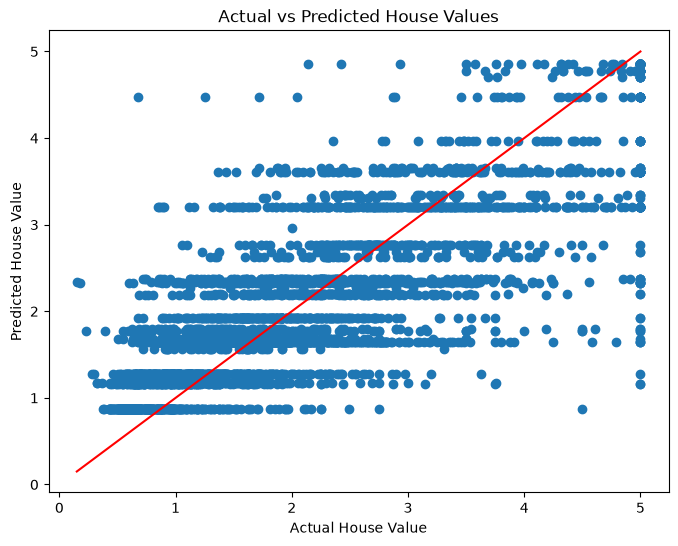

In [22]:
best_model=DecisionTreeRegressor(max_depth=5)
best_model.fit(X_train,y_train)
y_pred=best_model.predict(X_test)
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()